Qui testiamo i file di dati salvati

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# BDT

In [7]:
# riportiamo i risultati del BDT
import json

data_bdt_low = json.load(open("../results/bdt_auc/bdt_curva_low.json"))
data_bdt_high = json.load(open("../results/bdt_auc/bdt_curva_high.json"))
data_bdt_complete = json.load(open("../results/bdt_auc/bdt_curva_complete.json"))

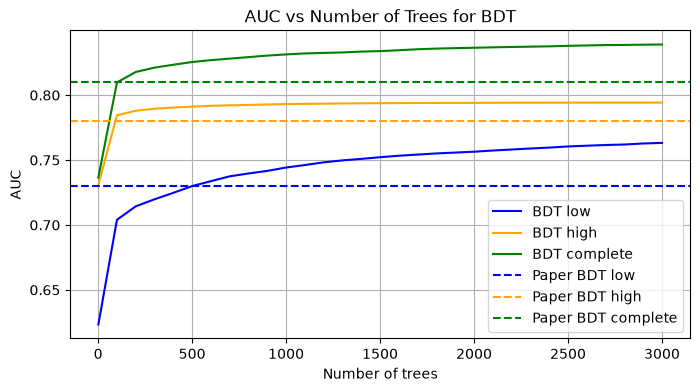

In [8]:
n_alberi_low = data_bdt_low["n_alberi"]
n_alberi_high = data_bdt_high["n_alberi"]
n_alberi_complete = data_bdt_complete["n_alberi"]

auc_bdt_low = data_bdt_low["auc_val"]
auc_bdt_high = data_bdt_high["auc_val"]
auc_bdt_complete = data_bdt_complete["auc_val"]

paper_bdt_low = 0.73
paper_bdt_high = 0.78
paper_bdt_complete = 0.81

plt.figure(figsize = (8,4))
plt.plot(n_alberi_low, auc_bdt_low, label = "BDT low", color = "blue")
plt.plot(n_alberi_high, auc_bdt_high, label = "BDT high", color = "orange")
plt.plot(n_alberi_complete, auc_bdt_complete, label = "BDT complete", color = "green")
# riga orizzontale per i valori di AUC riportati nel paper
plt.axhline(y = paper_bdt_low, color = "blue", linestyle = "--", label = "Paper BDT low")
plt.axhline(y = paper_bdt_high, color = "orange", linestyle = "--", label = "Paper BDT high")
plt.axhline(y = paper_bdt_complete, color = "green", linestyle = "--", label = "Paper BDT complete")
plt.xlabel("Number of trees")
plt.ylabel("AUC")
plt.title("AUC vs Number of Trees for BDT")
plt.legend()
plt.grid()
plt.show()


In [9]:
from pathlib import Path
import json

CARTELLA = Path("../results/bdt")
SET = ["low", "high", "complete"]
SEMI = range(5)

print(list(json.load(open(CARTELLA / "bdt_low_riepilogo.json")).keys()))
print(list(json.load(open(CARTELLA / "bdt_low_seme0_info.json")).keys()))
print(list(np.load(CARTELLA / "bdt_low_seme0_roc.npz").keys()))

['modello', 'feature_set', 'n_input', 'n_train', 'semi', 'auc_test', 'auc_medio', 'auc_dev_std']
['auc_test', 'n_alberi_usati', 'minuti']
['nome', 'auc', 'signal_efficiency', 'background_rejection']


In [10]:
COLORI = {"low": "blue", "high": "orange", "complete": "green"}
PAPER = {"low": 0.73, "high": 0.78, "complete": 0.81}

roc = {(s, k): np.load(CARTELLA / f"bdt_{s}_seme{k}_roc.npz")
       for s in SET for k in SEMI}

righe = []
for s in SET:
    a = np.array([float(roc[s, k]["auc"]) for k in SEMI])
    righe.append({
        "set": s,
        "AUC media": a.mean(),
        "dev. std": a.std(ddof=1),
        "min": a.min(),
        "max": a.max(),
        "AUC paper": PAPER[s],
        "delta": a.mean() - PAPER[s],
    })

pd.DataFrame(righe).round(4)

,set,AUC media,dev. std,min,max,AUC paper,delta
0,low,0.7626,0.0004,0.7622,0.7632,0.73,0.0326
1,high,0.7930,0.0001,0.7930,0.7931,0.78,0.0130
2,complete,0.8386,0.0002,0.8383,0.8388,0.81,0.0286


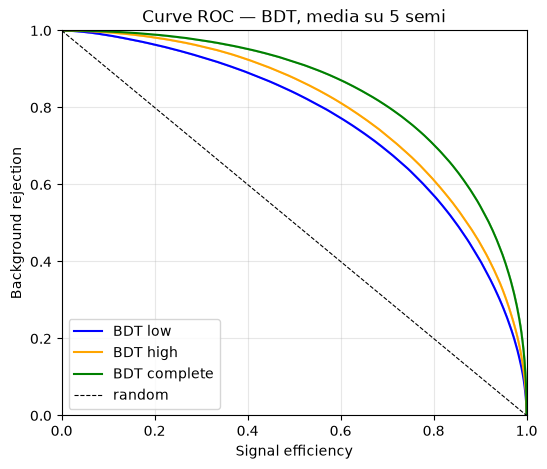

low       dev. std massima sulla curva: 0.0015
high      dev. std massima sulla curva: 0.0009
complete  dev. std massima sulla curva: 0.0014


In [11]:
GRIGLIA = np.linspace(0, 1, 1001)

media, deviazione = {}, {}
for s in SET:
    rigetti = np.array([
        np.interp(GRIGLIA, roc[s, k]["signal_efficiency"], roc[s, k]["background_rejection"])
        for k in SEMI
    ])
    media[s] = rigetti.mean(axis=0)
    deviazione[s] = rigetti.std(axis=0, ddof=1)

plt.figure(figsize=(6, 5))
for s in SET:
    plt.plot(GRIGLIA, media[s], color=COLORI[s], label=f"BDT {s}")
    plt.fill_between(GRIGLIA, media[s] - deviazione[s], media[s] + deviazione[s],
                     color=COLORI[s], alpha=0.3)
plt.plot([0, 1], [1, 0], "k--", lw=0.8, label="random")
plt.xlabel("Signal efficiency"); plt.ylabel("Background rejection")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.grid(alpha=0.3); plt.legend(loc="lower left")
plt.title("Curve ROC — BDT, media su 5 semi")
plt.show()

for s in SET:
    print(f"{s:9s} dev. std massima sulla curva: {deviazione[s].max():.4f}")

In [12]:
PUNTI = [0.5, 0.7, 0.9]
indici = [np.abs(GRIGLIA - p).argmin() for p in PUNTI]

tabella = {s: [f"{media[s][i]:.4f} ± {deviazione[s][i]:.4f}  (1/{1/(1-media[s][i]):.0f})"
               for i in indici] for s in SET}

pd.DataFrame(tabella, index=[f"eff_s = {p}" for p in PUNTI])

,low,high,complete
eff_s = 0.5,0.8388 ± 0.0006 (1/6),0.8764 ± 0.0002 (1/8),0.9188 ± 0.0003 (1/12)
eff_s = 0.7,0.6876 ± 0.0011 (1/3),0.7265 ± 0.0003 (1/4),0.8033 ± 0.0006 (1/5)
eff_s = 0.9,0.4025 ± 0.0010 (1/2),0.4469 ± 0.0002 (1/2),0.5443 ± 0.0009 (1/2)


# NN e DN

per il momento è disponibile solo lo shallow_high seme 0

In [13]:
percorso_file = "/home/alice/Deep-Learning/ExoticParticles_HEP/results/riproduzione/shallow_high_seme0_modello.pt"

dati = torch.load(percorso_file, map_location='cpu', weights_only=True)

print(type(dati))

<class 'collections.OrderedDict'>


In [14]:
# Stampa il nome di ogni layer e la forma (shape) del tensore associato
for nome_layer, tensore in dati.items():
    print(f"Layer: {nome_layer} | Dimensioni: {tensore.shape}")

Layer: nascosti.0.weight | Dimensioni: torch.Size([300, 7])
Layer: nascosti.0.bias | Dimensioni: torch.Size([300])
Layer: uscita.weight | Dimensioni: torch.Size([1, 300])
Layer: uscita.bias | Dimensioni: torch.Size([1])


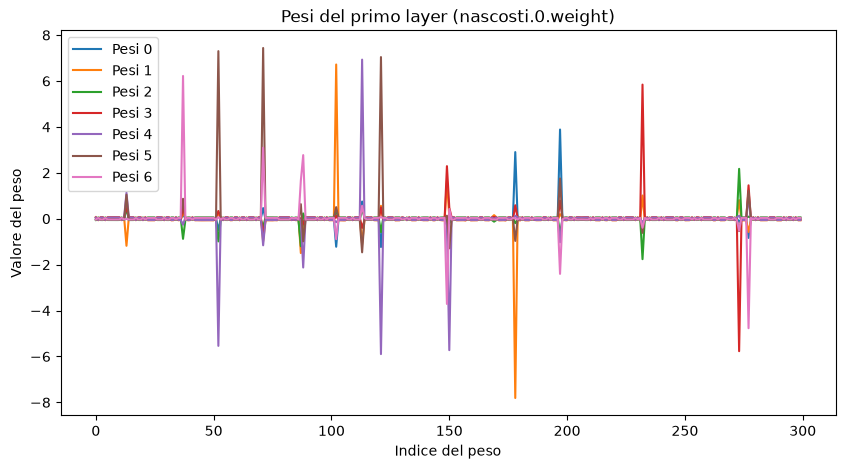

In [15]:
# visualizzazione dei pesi del primo layer (ad esempio)
primo_layer = list(dati.keys())[0]
plt.figure(figsize=(10, 5))
plt.plot(dati[primo_layer].numpy())
plt.title(f"Pesi del primo layer ({primo_layer})")
plt.xlabel("Indice del peso")
plt.ylabel("Valore del peso")
plt.legend([f"Pesi {i}" for i in range(dati[primo_layer].shape[0])])
plt.show()

/tmp/ipykernel_39051/4223863361.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  assi[2].set_xticklabels(HIGH_LEVEL, rotation=45, ha="right")


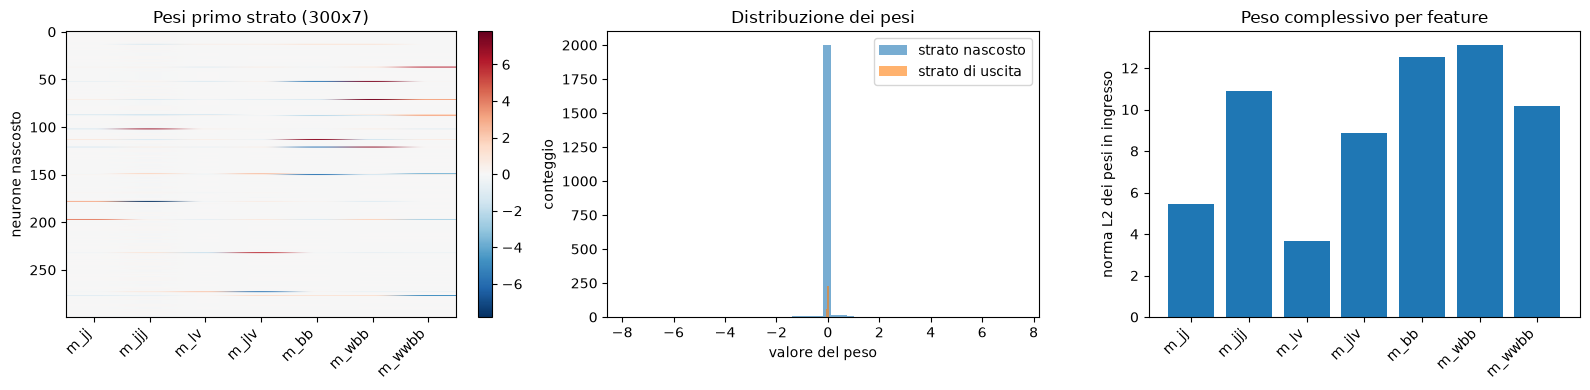

In [16]:
import sys
sys.path.append("/home/alice/Deep-Learning/ExoticParticles_HEP/src")
from features import HIGH_LEVEL

W1 = dati["nascosti.0.weight"].numpy()   # (300, 7)
b1 = dati["nascosti.0.bias"].numpy()
W2 = dati["uscita.weight"].numpy()       # (1, 300)

fig, assi = plt.subplots(1, 3, figsize=(16, 4))

# 1) heatmap del primo strato: 300 neuroni nascosti x 7 feature high-level
im = assi[0].imshow(W1, aspect="auto", cmap="RdBu_r",
                     vmin=-np.abs(W1).max(), vmax=np.abs(W1).max())
assi[0].set_xticks(range(7)); assi[0].set_xticklabels(HIGH_LEVEL, rotation=45, ha="right")
assi[0].set_ylabel("neurone nascosto")
assi[0].set_title("Pesi primo strato (300x7)")
fig.colorbar(im, ax=assi[0], fraction=0.046)

# 2) istogramma dei pesi (primo strato + strato di uscita)
assi[1].hist(W1.ravel(), bins=50, alpha=0.6, label="strato nascosto")
assi[1].hist(W2.ravel(), bins=50, alpha=0.6, label="strato di uscita")
assi[1].set_xlabel("valore del peso"); assi[1].set_ylabel("conteggio")
assi[1].set_title("Distribuzione dei pesi")
assi[1].legend()

# 3) norma dei pesi per feature in ingresso: proxy grezzo di "quanto pesa" ciascuna variabile
norme = np.linalg.norm(W1, axis=0)
assi[2].bar(HIGH_LEVEL, norme)
assi[2].set_xticklabels(HIGH_LEVEL, rotation=45, ha="right")
assi[2].set_ylabel("norma L2 dei pesi in ingresso")
assi[2].set_title("Peso complessivo per feature")

fig.tight_layout()
plt.show()

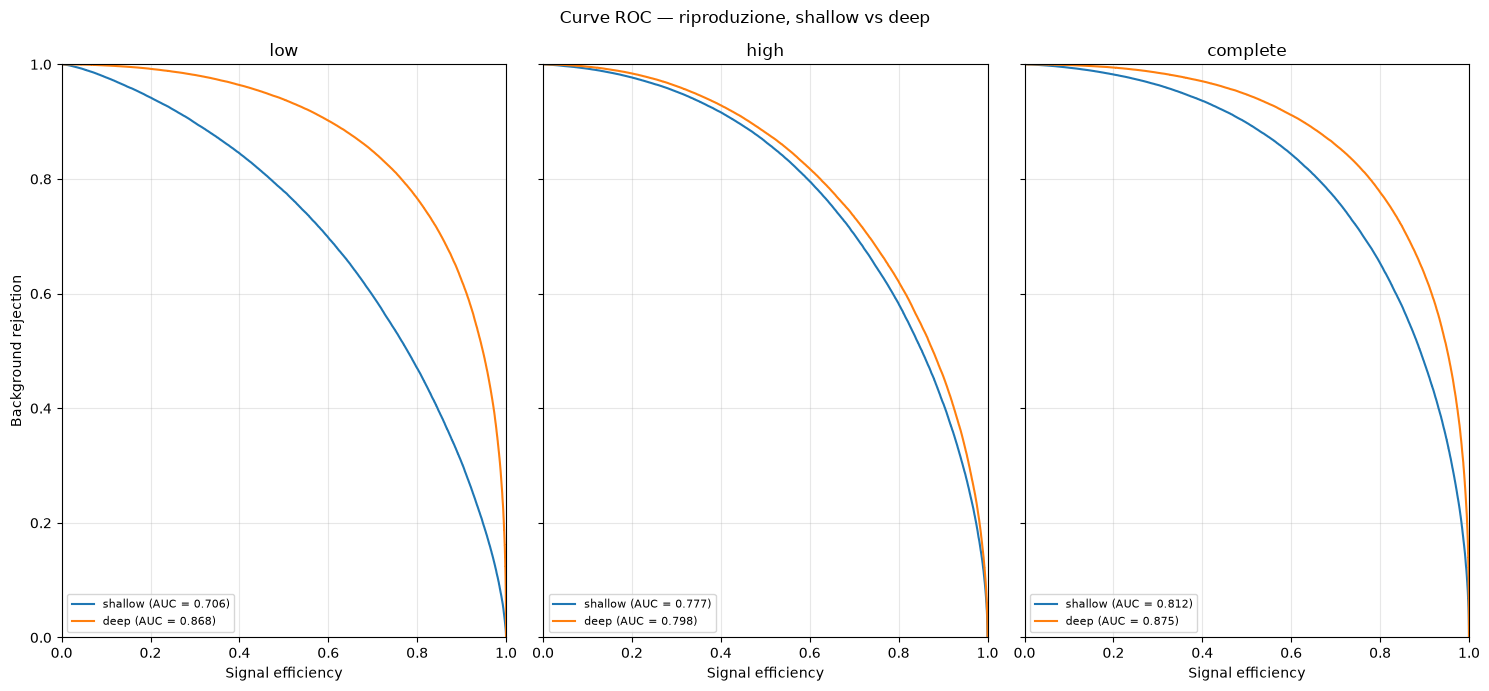

In [17]:
from pathlib import Path

CARTELLA_RIPRODUZIONE = Path("../results/riproduzione")
FEATURE_SETS = ["low", "high", "complete"]
MODELLI = ["shallow", "deep"]

roc_riproduzione = {(m, fs): np.load(CARTELLA_RIPRODUZIONE / f"{m}_{fs}_seme0_roc.npz")
                    for m in MODELLI for fs in FEATURE_SETS}

fig, assi = plt.subplots(1, 3, figsize=(15, 7), sharey=True)

for ax, fs in zip(assi, FEATURE_SETS):
    for modello in MODELLI:
        r = roc_riproduzione[modello, fs]
        ax.plot(r["signal_efficiency"], r["background_rejection"],
                label=f"{modello} (AUC = {float(r['auc']):.3f})")
    ax.set_xlabel("Signal efficiency")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
    ax.set_title(fs)

assi[0].set_ylabel("Background rejection")
fig.suptitle("Curve ROC — riproduzione, shallow vs deep")
fig.tight_layout()
plt.show()

In [18]:
import numpy as np
from evaluate import carica_curva

c = carica_curva("../results/riproduzione/shallow_high_seme0_roc.npz")
eff_s = c["signal_efficiency"]
eff_b = 1 - c["background_rejection"]

S_TOT, B_TOT, DELTA_B = 100.0, 1000.0, 50.0

s = S_TOT * eff_s
b = B_TOT * eff_b
sig = DELTA_B * eff_b

buoni = b > 0          # scarta le soglie che azzerano il fondo

def massimo(Z, nome):
    Z = np.where(buoni, Z, 0)
    i = np.nanargmax(Z)
    print(f"{nome:38s} {Z[i]:5.2f} sigma   (eff_s = {eff_s[i]:.3f}, eff_b = {eff_b[i]:.4f})")

with np.errstate(divide="ignore", invalid="ignore"):
    # 1. solo statistica
    massimo(s / np.sqrt(b), "s/sqrt(b), solo statistica")

    # 2. statistica + sistematico in quadratura  (quella gia' provata)
    massimo(s / np.sqrt(b + sig**2), "s/sqrt(b + sigma^2)")

    # 3. formula asintotica di Cowan, senza sistematico
    Z3 = np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s))
    massimo(Z3, "Cowan, senza sistematico")

    # 4. formula asintotica di Cowan, con sistematico
    num = (s + b) * (b + sig**2) / (b**2 + (s + b) * sig**2)
    Z4 = np.sqrt(2 * ((s + b) * np.log(num)
                      - (b**2 / sig**2) * np.log(1 + sig**2 * s / (b * (b + sig**2)))))
    massimo(Z4, "Cowan, con sistematico")

# 5. soglia fissa al 90% di reiezione del fondo, invece che ottimizzata
i90 = np.argmin(np.abs(eff_b - 0.10))
z90 = s[i90] / np.sqrt(b[i90] + sig[i90]**2)
print(f"{'soglia fissa a rej = 0.9':38s} {z90:5.2f} sigma   (eff_s = {eff_s[i90]:.3f})")

s/sqrt(b), solo statistica              4.37 sigma   (eff_s = 0.382, eff_b = 0.0763)
s/sqrt(b + sigma^2)                     4.13 sigma   (eff_s = 0.279, eff_b = 0.0415)
Cowan, senza sistematico                4.09 sigma   (eff_s = 0.470, eff_b = 0.1171)
Cowan, con sistematico                  3.73 sigma   (eff_s = 0.315, eff_b = 0.0520)
soglia fissa a rej = 0.9                3.89 sigma   (eff_s = 0.435)


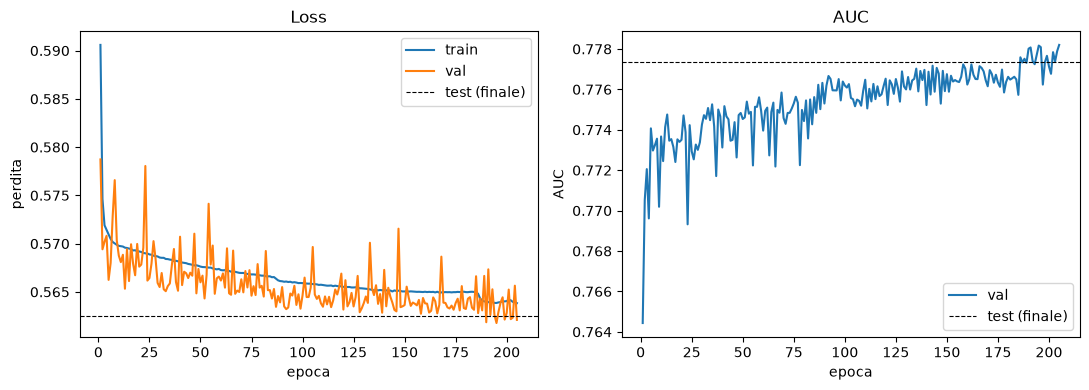

tempo di training: 247.8 minuti


In [19]:
import json

with open("/home/alice/Deep-Learning/ExoticParticles_HEP/results/riproduzione/shallow_high_seme0_storia.json") as f:
    storia = json.load(f)

epoche = range(1, len(storia["perdita_train"]) + 1)

fig, assi = plt.subplots(1, 2, figsize=(11, 4))

assi[0].plot(epoche, storia["perdita_train"], label="train")
assi[0].plot(epoche, storia["perdita_val"], label="val")
assi[0].axhline(storia["perdita_test"], color="k", linestyle="--", linewidth=0.8, label="test (finale)")
assi[0].set_xlabel("epoca"); assi[0].set_ylabel("perdita")
assi[0].set_title("Loss"); assi[0].legend()

assi[1].plot(epoche, storia["auc_val"], label="val")
assi[1].axhline(storia["auc_test"], color="k", linestyle="--", linewidth=0.8, label="test (finale)")
assi[1].set_xlabel("epoca"); assi[1].set_ylabel("AUC")
assi[1].set_title("AUC"); assi[1].legend()

fig.tight_layout()
plt.show()

print(f"tempo di training: {storia['minuti']:.1f} minuti")

### Perché queste curve, pur "brutte", sono il risultato corretto

Il grafico mostra tre cose che a prima vista sembrano segnali di malfunzionamento:

1. la perdita di **training** scende fino all'epoca ~75-100 e poi **risale** (0.5695 → 0.5815);
2. la perdita di **validation** è molto rumorosa, con picchi sempre più frequenti verso la fine;
3. l'**AUC** raggiunge il massimo intorno all'epoca 50-80 e poi degrada lentamente.

Nessuna di queste è un errore di implementazione. Sono la conseguenza diretta
dello schema di ottimizzazione descritto nei Methods del paper.

#### Il passo effettivo cresce durante l'addestramento

Con il momentum, l'entità dell'aggiornamento dei pesi non è il learning rate $\eta$,
ma circa

$$\eta_{\text{eff}} \simeq \frac{\eta}{1-\mu}$$

perché l'inerzia accumula i gradienti delle iterazioni precedenti. Nel paper agiscono
due schedule in direzioni **opposte**:

| | andamento su 200 epoche | fattore |
|---|---|---|
| learning rate | $0.05 \to 0.0177$ (decadimento per batch) | $\div 2.8$ |
| $1/(1-\mu)$ | $10 \to 100$ (rampa del momentum $0.9 \to 0.99$) | $\times 10$ |
| **passo effettivo** | $0.50 \to 1.77$ | $\times 3.5$ |

Il secondo effetto domina: il passo effettivo resta piatto fino all'epoca ~100,
poi **triplica**. Da lì in avanti il modello non converge più, orbita attorno al
minimo con passi troppo grandi. Il minimo della perdita di training cade infatti
proprio dove la curva del passo effettivo comincia a salire.

#### Perché non è overfitting

In presenza di overfitting la perdita di training continuerebbe a **scendere**
mentre quella di validation sale. Qui salgono entrambe, e la validation resta
sistematicamente **sotto** quella di training. Il modello non sta memorizzando il
training set: sta semplicemente oscillando.

#### Perché il risultato finale è comunque valido

`addestra()` conserva i pesi dell'**epoca migliore**, non quelli dell'ultima. Il
modello valutato sul test set è quindi quello dell'epoca ~75, non quello dell'epoca 200.

**AUC sul test: 0.7750**, contro lo **0.777** riportato dal paper per la rete shallow
sulle feature high-level. La riproduzione è riuscita.

#### Due osservazioni per la relazione

**Il budget di epoche è in parte sprecato.** Questa configurazione era convergita
intorno all'epoca 50, ma `EPOCHE_RAMPA = 200` impedisce all'early stopping di
attivarsi prima (nel paper l'arresto è consentito solo dopo che il momentum ha
raggiunto il massimo). Sono state quindi eseguite ~150 epoche che hanno solo
peggiorato il modello. È coerente con l'attesa: con 7 variabili già costruite dai
fisici c'è poco da scoprire, e infatti anche il BDT sulle stesse feature si fermava
presto. Resta da verificare se lo stesso accada per le reti profonde sulle low-level,
dove il modello deve costruirsi le combinazioni non lineari da solo.

**È la motivazione empirica della prima estensione.** Adam adatta il passo per ogni
parametro e non presenta questa patologia. Affiancare questa curva a quella ottenuta
con lo stack moderno fornisce una dimostrazione diretta — non un'affermazione generica
— di cosa sia cambiato nelle tecniche di ottimizzazione dal 2014 a oggi.